Analysing data of Global tech talent and workforce survey gotten from kaggle.com

In [ ]:
#first steps:
#importing libraries to work with the dataset

import pandas as pd
import numpy as np

df = pd.read_csv('saas-sample-500.csv')
#checking the dataset
df.head()
df.info()
#setting data types for the columns
datecols = ['startDate', 'createdAt', 'publishedAt', 'scrapedAt']
print(datecols)
df[datecols] = df[datecols].apply(pd.to_datetime, errors='coerce', format='ISO8601')


<class 'pandas.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   productId          354 non-null    str  
 1   name               354 non-null    str  
 2   tagline            354 non-null    str  
 3   description        354 non-null    str  
 4   url                354 non-null    str  
 5   websiteUrl         354 non-null    str  
 6   avatarUrl          354 non-null    str  
 7   monthlyRevenueUSD  354 non-null    int64
 8   numFollowers       354 non-null    int64
 9   twitterHandle      124 non-null    str  
 10  startDate          354 non-null    str  
 11  createdAt          354 non-null    str  
 12  publishedAt        354 non-null    str  
 13  updatedAt          354 non-null    str  
 14  founderUserIds     354 non-null    str  
 15  verticals          354 non-null    str  
 16  revenueModels      354 non-null    str  
 17  funding            354 non-

In [ ]:
category_columns = df.select_dtypes(include = 'str').columns.tolist()
numeric_columns = df.select_dtypes(include = 'int64').columns.tolist()
timeseries_columns = df.select_dtypes(exclude=['object', 'int64', 'float64']).columns.tolist()
print(category_columns)
print(numeric_columns)
print(timeseries_columns)
# df.info()
#checking for missing values
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)
# fill missing values in the handle and platform columns with 'Unknown'
df.fillna({'twitterHandle': 'Unknown', 'platforms': 'Unknown'}, inplace=True)
print(df.columns)
keycolumns = ['productId', 'url', 'tagline', 'monthlyRevenueUSD', 'numFollowers', 'platforms', 'revenueModels', 'verticals', 'funding', 'startDate', 'createdAt', 'publishedAt', 'scrapedAt']
df[keycolumns].describe().transpose() #summarizing the key columns of the dataset


['productId', 'name', 'tagline', 'description', 'url', 'websiteUrl', 'avatarUrl', 'twitterHandle', 'updatedAt', 'founderUserIds', 'verticals', 'revenueModels', 'funding', 'platforms', 'allTags']
['monthlyRevenueUSD', 'numFollowers']
['startDate', 'createdAt', 'publishedAt', 'scrapedAt']
Index(['productId', 'name', 'tagline', 'description', 'url', 'websiteUrl',
       'avatarUrl', 'monthlyRevenueUSD', 'numFollowers', 'twitterHandle',
       'startDate', 'createdAt', 'publishedAt', 'updatedAt', 'founderUserIds',
       'verticals', 'revenueModels', 'funding', 'platforms', 'allTags',
       'scrapedAt'],
      dtype='str')


,count,mean,min,25%,50%,75%,max,std
monthlyRevenueUSD,354.0,1606528.576271,0.0,0.0,0.0,11.5,567890678.0,30182937.556638
numFollowers,354.0,0.997175,0.0,1.0,1.0,1.0,2.0,0.092144
startDate,354,2025-07-31 19:51:51.864406,1994-01-01 00:00:00,2025-09-01 00:00:00,2026-01-01 00:00:00,2026-03-01 00:00:00,2026-09-01 00:00:00,NaN


In [ ]:
total_observations = len(df)
print(f'Total observations: {total_observations}')

average_monthly_revenue = df['monthlyRevenueUSD'].mean()
median_monthly_revenue = df['monthlyRevenueUSD'].median()
max_monthly_revenue = df['monthlyRevenueUSD'].max()
total_monthly_revenue = df['monthlyRevenueUSD'].sum()
lowest_monthly_revenue = df['monthlyRevenueUSD'].min()
print(f'Total monthly revenue: ${total_monthly_revenue:,.2f} and the maximum monthly revenue is ${max_monthly_revenue:,.2f} and the lowest monthly revenue is ${lowest_monthly_revenue:,.2f}')
print(f'Average monthly revenue: ${average_monthly_revenue:,.2f} but the realistic rate a person is making is ${median_monthly_revenue:.2f} per month')
average_followers = df['numFollowers'].mean().round(0)
median_followers = df['numFollowers'].median().round(0)
total_followers = df['numFollowers'].sum()
print(f'The Average number of followers a person has is {average_followers}\n total followers across all repondendts is {total_followers}')
df['startDate'].dt.to_period('Y').value_counts()



Total observations: 354
Total monthly revenue: $568,711,116.00 and the maximum monthly revenue is $567,890,678.00 and the lowest monthly revenue is $0.00
Average monthly revenue: $1,606,528.58 but the realistic rate a person is making is $0.00 per month
The Average number of followers a person has is 1.0
 total followers across all repondendts is 353


startDate
2026    220
2025    102
2024     13
2023     11
2016      2
2022      2
1994      1
2020      1
2019      1
2017      1
Freq: Y-DEC, Name: count, dtype: int64

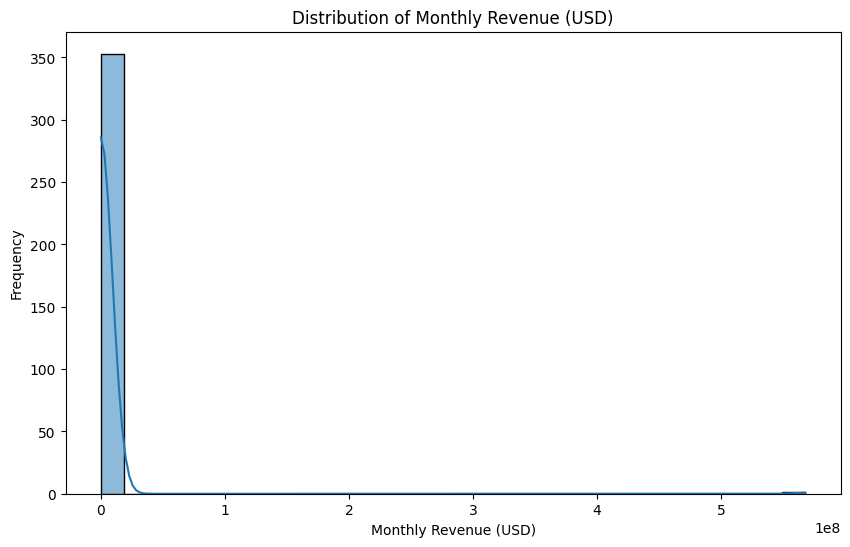

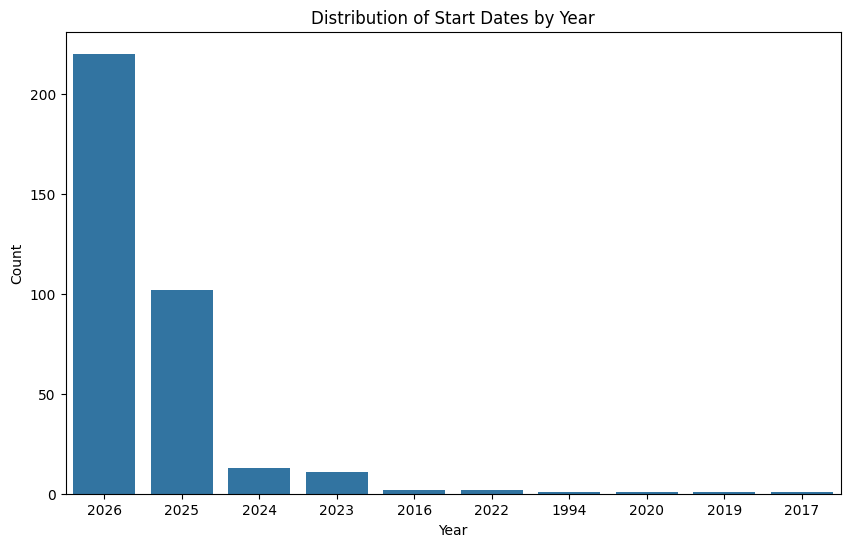

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df['monthlyRevenueUSD'], bins=30, kde=True)
plt.title('Distribution of Monthly Revenue (USD)')
plt.xlabel('Monthly Revenue (USD)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['startDate'].dt.to_period('Y').value_counts().index.astype(str), y=df['startDate'].dt.to_period('Y').value_counts().values)
plt.title('Distribution of Start Dates by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()